In [1]:
import pandas as pd
from pathlib import Path

from IPython.core.pylabtools import figsize

data_path = Path('../data/')

data = pd.read_csv(data_path / 'cleaned_data.csv')

data.head()

,RNTRD Rent (weekly) Ranges,Negative income,Nil income,"$1-$149 ($1-$7,799)","$150-$299 ($7,800-$15,599)","$300-$399 ($15,600-$20,799)","$400-$499 ($20,800-$25,999)","$500-$649 ($26,000-$33,799)","$650-$799 ($33,800-$41,599)","$800-$999 ($41,600-$51,999)",...,"$4,000-$4,499 ($208,000-$233,999)","$4,500-$4,999 ($234,000-$259,999)","$5,000-$5,999 ($260,000-$311,999)","$6,000-$7,999 ($312,000-$415,999)","$8,000 or more ($416,000 or more)",Partial income stated,All incomes not stated,Not applicable,Total,Suburb
0,$1-$74,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,Braidwood
1,$75-$99,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Braidwood
2,$100-$124,0,0,0,0,0,5,0,0,0,...,0,0,0,0,0,0,0,0,10,Braidwood
3,$125-$149,0,0,0,0,0,0,5,0,0,...,0,0,0,0,0,0,0,0,5,Braidwood
4,$150-$174,0,0,0,0,0,0,7,5,0,...,0,0,0,0,0,0,3,0,20,Braidwood


We will start off by measuring **Rental Stress**. In Australia, this means when rent exceeds 30% of the total weekly household income for a household.

Rental stress ratio is given by the formula  $\frac{Rent}{Income}$. Now because our income and rent are given as ranges, there are a few methods of handling this. We will start by using the simple approach which is the midpoint of all the ranges.

In [2]:
old_columns = data.columns[1:]
print(old_columns)

Index(['Negative income', 'Nil income', '$1-$149 ($1-$7,799)',
       '$150-$299 ($7,800-$15,599)', '$300-$399 ($15,600-$20,799)',
       '$400-$499 ($20,800-$25,999)', '$500-$649 ($26,000-$33,799)',
       '$650-$799 ($33,800-$41,599)', '$800-$999 ($41,600-$51,999)',
       '$1,000-$1,249 ($52,000-$64,999)', '$1,250-$1,499 ($65,000-$77,999)',
       '$1,500-$1,749 ($78,000-$90,999)', '$1,750-$1,999 ($91,000-$103,999)',
       '$2,000-$2,499 ($104,000-$129,999)',
       '$2,500-$2,999 ($130,000-$155,999)',
       '$3,000-$3,499 ($156,000-$181,999)',
       '$3,500-$3,999 ($182,000-$207,999)',
       '$4,000-$4,499 ($208,000-$233,999)',
       '$4,500-$4,999 ($234,000-$259,999)',
       '$5,000-$5,999 ($260,000-$311,999)',
       '$6,000-$7,999 ($312,000-$415,999)',
       '$8,000 or more ($416,000 or more)', 'Partial income stated',
       'All incomes not stated', 'Not applicable', 'Total', 'Suburb'],
      dtype='object')


We also need to find a way to handle the worded columns like 'Negative income', 'Nil income' etc. These will be ignored in the ratio calculations and will instead be handled in a separate section of our analysis.

In [3]:
# how the original data looks
data

,RNTRD Rent (weekly) Ranges,Negative income,Nil income,"$1-$149 ($1-$7,799)","$150-$299 ($7,800-$15,599)","$300-$399 ($15,600-$20,799)","$400-$499 ($20,800-$25,999)","$500-$649 ($26,000-$33,799)","$650-$799 ($33,800-$41,599)","$800-$999 ($41,600-$51,999)",...,"$4,000-$4,499 ($208,000-$233,999)","$4,500-$4,999 ($234,000-$259,999)","$5,000-$5,999 ($260,000-$311,999)","$6,000-$7,999 ($312,000-$415,999)","$8,000 or more ($416,000 or more)",Partial income stated,All incomes not stated,Not applicable,Total,Suburb
0,$1-$74,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,Braidwood
1,$75-$99,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Braidwood
2,$100-$124,0,0,0,0,0,5,0,0,0,...,0,0,0,0,0,0,0,0,10,Braidwood
3,$125-$149,0,0,0,0,0,0,5,0,0,...,0,0,0,0,0,0,0,0,5,Braidwood
4,$150-$174,0,0,0,0,0,0,7,5,0,...,0,0,0,0,0,0,3,0,20,Braidwood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68987,$850-$949,57,310,78,124,128,183,205,339,435,...,1420,4130,2952,3127,887,2120,146,20,28378,Total
68988,$950 and over,170,748,185,216,285,387,516,672,892,...,1834,8297,5539,7449,3682,3876,483,59,53785,Total
68989,Not stated,2150,5375,1490,3159,4886,6629,4918,5653,6371,...,1123,2742,1139,947,497,10403,13789,505,114130,Total
68990,Not applicable,23971,91005,46555,70483,113846,370322,218740,378870,363831,...,162502,298297,217279,193703,77283,338731,143483,1436069,7980459,Total


In [4]:
# make the index of the data what it should be (weekly rent ranges)
numerical_data = data.copy()
numerical_data.index = data.iloc[:, 0]
numerical_data.drop(columns=data.columns[0], inplace=True)
numerical_data

,Negative income,Nil income,"$1-$149 ($1-$7,799)","$150-$299 ($7,800-$15,599)","$300-$399 ($15,600-$20,799)","$400-$499 ($20,800-$25,999)","$500-$649 ($26,000-$33,799)","$650-$799 ($33,800-$41,599)","$800-$999 ($41,600-$51,999)","$1,000-$1,249 ($52,000-$64,999)",...,"$4,000-$4,499 ($208,000-$233,999)","$4,500-$4,999 ($234,000-$259,999)","$5,000-$5,999 ($260,000-$311,999)","$6,000-$7,999 ($312,000-$415,999)","$8,000 or more ($416,000 or more)",Partial income stated,All incomes not stated,Not applicable,Total,Suburb
RNTRD Rent (weekly) Ranges,,,,,,,,,,,,,,,,,,,,,
$1-$74,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3,Braidwood
$75-$99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Braidwood
$100-$124,0,0,0,0,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,10,Braidwood
$125-$149,0,0,0,0,0,0,5,0,0,0,...,0,0,0,0,0,0,0,0,5,Braidwood
$150-$174,0,0,0,0,0,0,7,5,0,0,...,0,0,0,0,0,0,3,0,20,Braidwood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
$850-$949,57,310,78,124,128,183,205,339,435,654,...,1420,4130,2952,3127,887,2120,146,20,28378,Total
$950 and over,170,748,185,216,285,387,516,672,892,1256,...,1834,8297,5539,7449,3682,3876,483,59,53785,Total
Not stated,2150,5375,1490,3159,4886,6629,4918,5653,6371,6956,...,1123,2742,1139,947,497,10403,13789,505,114130,Total


We now need to have information stored about which rows and columns we want to use for numerical calculations. We will use a boolean mask for both the rows and columns to make this happen.

In [5]:
# this mask denotes True if a column has any numbers, in which case those columns will be required for our Rent Stress calculations.
column_mask = pd.Series([any(c.isdigit() for c in col) for col in numerical_data.columns], index=numerical_data.columns)
print(column_mask)

Negative income                      False
Nil income                           False
$1-$149 ($1-$7,799)                   True
$150-$299 ($7,800-$15,599)            True
$300-$399 ($15,600-$20,799)           True
$400-$499 ($20,800-$25,999)           True
$500-$649 ($26,000-$33,799)           True
$650-$799 ($33,800-$41,599)           True
$800-$999 ($41,600-$51,999)           True
$1,000-$1,249 ($52,000-$64,999)       True
$1,250-$1,499 ($65,000-$77,999)       True
$1,500-$1,749 ($78,000-$90,999)       True
$1,750-$1,999 ($91,000-$103,999)      True
$2,000-$2,499 ($104,000-$129,999)     True
$2,500-$2,999 ($130,000-$155,999)     True
$3,000-$3,499 ($156,000-$181,999)     True
$3,500-$3,999 ($182,000-$207,999)     True
$4,000-$4,499 ($208,000-$233,999)     True
$4,500-$4,999 ($234,000-$259,999)     True
$5,000-$5,999 ($260,000-$311,999)     True
$6,000-$7,999 ($312,000-$415,999)     True
$8,000 or more ($416,000 or more)     True
Partial income stated                False
All incomes

In [6]:
# repeat the same mask idea but for the rows. we wrap both masks in a Series in case we need to get the negation of them to deal with the non-numeric rows or columns
row_mask = pd.Series([any(c.isdigit() for c in row) for row in numerical_data.index], index=numerical_data.index)
print(row_mask)

RNTRD Rent (weekly) Ranges
$1-$74             True
$75-$99            True
$100-$124          True
$125-$149          True
$150-$174          True
                  ...  
$850-$949          True
$950 and over      True
Not stated        False
Not applicable    False
Total             False
Length: 68992, dtype: bool


In [7]:
# example of the row and column masks at work
numerical_data.loc[row_mask, column_mask]

,"$1-$149 ($1-$7,799)","$150-$299 ($7,800-$15,599)","$300-$399 ($15,600-$20,799)","$400-$499 ($20,800-$25,999)","$500-$649 ($26,000-$33,799)","$650-$799 ($33,800-$41,599)","$800-$999 ($41,600-$51,999)","$1,000-$1,249 ($52,000-$64,999)","$1,250-$1,499 ($65,000-$77,999)","$1,500-$1,749 ($78,000-$90,999)","$1,750-$1,999 ($91,000-$103,999)","$2,000-$2,499 ($104,000-$129,999)","$2,500-$2,999 ($130,000-$155,999)","$3,000-$3,499 ($156,000-$181,999)","$3,500-$3,999 ($182,000-$207,999)","$4,000-$4,499 ($208,000-$233,999)","$4,500-$4,999 ($234,000-$259,999)","$5,000-$5,999 ($260,000-$311,999)","$6,000-$7,999 ($312,000-$415,999)","$8,000 or more ($416,000 or more)"
RNTRD Rent (weekly) Ranges,,,,,,,,,,,,,,,,,,,,
$1-$74,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
$75-$99,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
$100-$124,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
$125-$149,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
$150-$174,0,0,0,0,7,5,0,0,3,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
$550-$649,598,811,1204,1767,3040,4263,5654,8810,11595,11446,12381,34109,23244,23077,14671,7976,14498,7572,5222,839
$650-$749,300,440,506,753,1154,1618,2166,3323,4251,4243,4729,13272,9817,11324,8294,5149,10741,6261,5051,990
$750-$849,136,213,248,319,463,713,912,1408,1848,1786,2048,5485,4175,5176,3882,2787,6743,4562,4324,960


Before we can calculate any rent, we must decide on discrete numeric values for each rent and income bracket.
The easy options are:
- Taking the lower bound (pessimistic for income, optimistic for rent)
- Taking the upper bound (pessimistic for rent, optimistic for income)
- Taking the exact midpoint of the range.

For our purposes, we will choose the last option as it is least biased.

We start by extracting the endpoints of each income and rent range and storing it.

In [8]:
import re
import numpy as np
# extract the numerical endpoints of each range
income_endpoints = []
for col in numerical_data.loc[:, column_mask].columns:
    # extract all numbers
    numbers = re.findall(r'\d+', col.replace(',', ''))
    # if we reach the "$8000 or more" column
    if len(numbers) == 2:
        income_endpoints.append((int(numbers[0]), np.inf))
    else:
        income_endpoints.append((int(numbers[0]), int(numbers[1])))

In [9]:
# repeat the same process for rows
rent_endpoints = []
for row in numerical_data.loc[row_mask, :].index:
    numbers = re.findall(r'\d+', row.replace(',', ''))
    if len(numbers) == 1:
        rent_endpoints.append((int(numbers[0]), np.inf))
    else:
        rent_endpoints.append((int(numbers[0]), int(numbers[1])))

We now take a copy of the numerical_data dataframe and replace each column and rent label with its range midpoint.

In [10]:
calculations = numerical_data.copy()
calculations = calculations.loc[row_mask, column_mask]
calculations.columns = [a if b == np.inf else (a+b)/2 for a, b in income_endpoints]
calculations.index = [a if b == np.inf else (a+b)/2 for a, b in rent_endpoints]
calculations

,75.0,224.5,349.5,449.5,574.5,724.5,899.5,1124.5,1374.5,1624.5,1874.5,2249.5,2749.5,3249.5,3749.5,4249.5,4749.5,5499.5,6999.5,8000.0
37.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
87.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
112.0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
137.0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
162.0,0,0,0,0,7,5,0,0,3,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599.5,598,811,1204,1767,3040,4263,5654,8810,11595,11446,12381,34109,23244,23077,14671,7976,14498,7572,5222,839
699.5,300,440,506,753,1154,1618,2166,3323,4251,4243,4729,13272,9817,11324,8294,5149,10741,6261,5051,990
799.5,136,213,248,319,463,713,912,1408,1848,1786,2048,5485,4175,5176,3882,2787,6743,4562,4324,960
899.5,78,124,128,183,205,339,435,654,783,830,894,2455,1803,2404,1897,1420,4130,2952,3127,887


Along the way, we also make sure that we take the total contribution from each household for the total number of households belong to **X** rent range and **Y** household income bracket.

In [11]:
all_suburb_sums = {}
for num in calculations.index.unique():
    all_suburb_sums[num] = calculations.loc[num, :].sum(axis=0)
all_suburbs_df = pd.DataFrame(all_suburb_sums).T
all_suburbs_df

,75.0,224.5,349.5,449.5,574.5,724.5,899.5,1124.5,1374.5,1624.5,1874.5,2249.5,2749.5,3249.5,3749.5,4249.5,4749.5,5499.5,6999.5,8000.0
37.5,994,5864,5806,5890,2766,2914,2685,2522,2470,1908,1695,4027,1652,2358,1124,615,1936,906,695,202
87.0,1141,8645,10363,8088,3267,3026,2374,1766,1494,923,785,1330,569,557,308,153,446,198,102,46
112.0,1807,11309,35142,66765,14439,9442,10539,6284,4844,3036,2235,3774,1718,1367,729,348,1196,405,308,127
137.0,907,4536,11074,17301,12100,6871,5823,4312,3364,1779,1376,2205,999,782,404,250,550,196,125,83
162.0,1066,5102,12523,18563,19995,17454,11564,9546,7379,4212,3011,5192,2050,1329,655,396,682,250,180,116
187.0,962,4334,12482,21396,23470,14745,12018,9034,6673,3653,2784,4206,1647,1012,444,277,593,206,160,126
212.0,1119,5131,13257,21936,28766,21578,22989,18946,14617,8453,6839,10830,4081,2598,1093,463,1097,414,236,159
237.0,684,2547,6735,12359,19074,15685,17225,15241,11143,6865,4904,8022,2807,1652,703,296,715,240,164,108
262.0,1060,4406,10717,19123,32709,27334,31156,32502,27034,17593,13830,21910,10080,5871,2387,1022,1694,517,258,213
287.0,706,2286,6344,11389,21801,20447,25067,27599,23792,15071,11613,18240,6514,3521,1429,652,1133,369,244,136


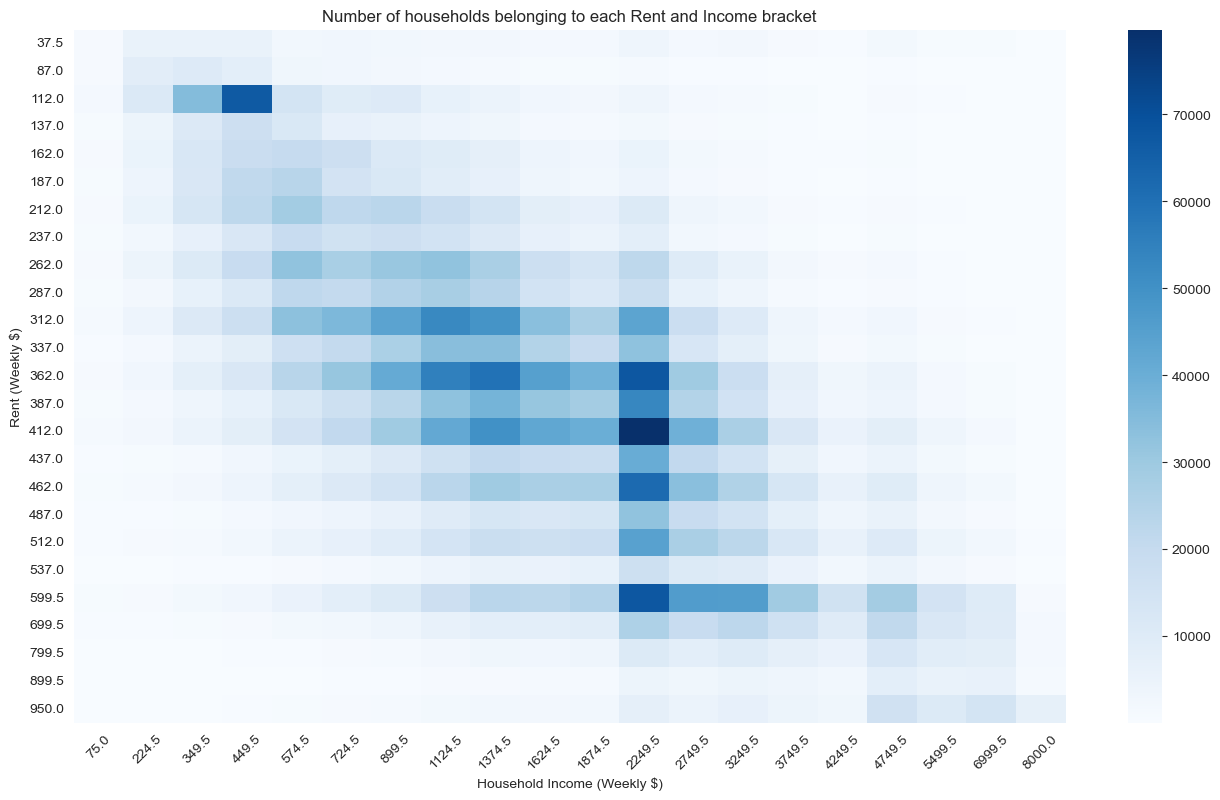

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 9))
sns.heatmap(all_suburbs_df, cmap='Blues')
plt.title('Number of households belonging to each Rent and Income bracket')
plt.xlabel('Household Income (Weekly $)')
plt.ylabel('Rent (Weekly $)')
plt.xticks(rotation=45)
plt.show()

In [13]:
income_vals = all_suburbs_df.columns.values[:, None]
rent_vals = all_suburbs_df.index.values[None, :]
rent_proportions = np.minimum(rent_vals / income_vals, 1)
rent_proportions_df = pd.DataFrame(rent_proportions.T, index=all_suburbs_df.index, columns=all_suburbs_df.columns)
rent_proportions_df

,75.0,224.5,349.5,449.5,574.5,724.5,899.5,1124.5,1374.5,1624.5,1874.5,2249.5,2749.5,3249.5,3749.5,4249.5,4749.5,5499.5,6999.5,8000.0
37.5,0.5,0.167038,0.107296,0.083426,0.065274,0.051760,0.041690,0.033348,0.027283,0.023084,0.020005,0.016670,0.013639,0.011540,0.010001,0.008825,0.007896,0.006819,0.005358,0.004687
87.0,1.0,0.387528,0.248927,0.193548,0.151436,0.120083,0.096720,0.077368,0.063296,0.053555,0.046412,0.038675,0.031642,0.026773,0.023203,0.020473,0.018318,0.015820,0.012429,0.010875
112.0,1.0,0.498886,0.320458,0.249166,0.194952,0.154589,0.124514,0.099600,0.081484,0.068944,0.059749,0.049789,0.040735,0.034467,0.029871,0.026356,0.023581,0.020365,0.016001,0.014000
137.0,1.0,0.610245,0.391989,0.304783,0.238468,0.189096,0.152307,0.121832,0.099673,0.084334,0.073086,0.060902,0.049827,0.042160,0.036538,0.032239,0.028845,0.024911,0.019573,0.017125
162.0,1.0,0.721604,0.463519,0.360400,0.281984,0.223602,0.180100,0.144064,0.117861,0.099723,0.086423,0.072016,0.058920,0.049854,0.043206,0.038122,0.034109,0.029457,0.023145,0.020250
187.0,1.0,0.832962,0.535050,0.416018,0.325500,0.258109,0.207893,0.166296,0.136049,0.115112,0.099760,0.083130,0.068012,0.057547,0.049873,0.044005,0.039373,0.034003,0.026716,0.023375
212.0,1.0,0.944321,0.606581,0.471635,0.369017,0.292616,0.235686,0.188528,0.154238,0.130502,0.113097,0.094243,0.077105,0.065241,0.056541,0.049888,0.044636,0.038549,0.030288,0.026500
237.0,1.0,1.000000,0.678112,0.527253,0.412533,0.327122,0.263480,0.210760,0.172426,0.145891,0.126434,0.105357,0.086197,0.072934,0.063208,0.055771,0.049900,0.043095,0.033860,0.029625
262.0,1.0,1.000000,0.749642,0.582870,0.456049,0.361629,0.291273,0.232992,0.190615,0.161280,0.139771,0.116470,0.095290,0.080628,0.069876,0.061654,0.055164,0.047641,0.037431,0.032750
287.0,1.0,1.000000,0.821173,0.638487,0.499565,0.396135,0.319066,0.255225,0.208803,0.176670,0.153107,0.127584,0.104383,0.088321,0.076544,0.067537,0.060427,0.052187,0.041003,0.035875


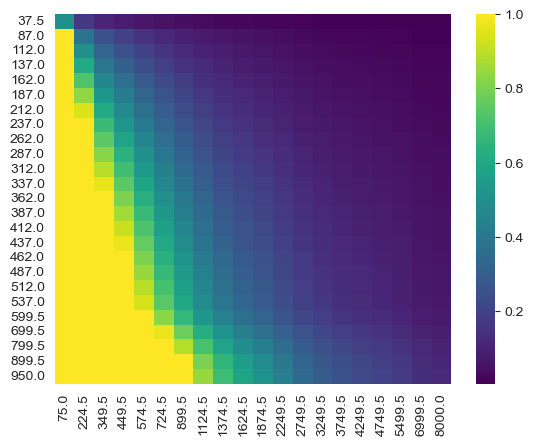

In [14]:
sns.heatmap(rent_proportions_df, cmap='viridis')
plt.show()

It may be more useful to look at all the households in terms of whether their rent stress is considered **Low (0-20%)**, **Moderate (20-30%)**, **High (30-50%)** or **Extreme (50%+)**. So we will now bin the rent proportions dataframe.

In [15]:
bins = np.array([0, 0.2, 0.3, 0.5])
rent_bin_labels = ['Low', 'Moderate', 'High', 'Extreme']
binned_rent_proportions_df = pd.DataFrame(np.digitize(rent_proportions_df.values, bins) - 1, index=rent_proportions_df.index, columns=rent_proportions_df.columns)
binned_rent_proportions_df

,75.0,224.5,349.5,449.5,574.5,724.5,899.5,1124.5,1374.5,1624.5,1874.5,2249.5,2749.5,3249.5,3749.5,4249.5,4749.5,5499.5,6999.5,8000.0
37.5,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
87.0,3,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
112.0,3,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
137.0,3,3,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
162.0,3,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
187.0,3,3,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
212.0,3,3,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
237.0,3,3,3,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0
262.0,3,3,3,3,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0
287.0,3,3,3,3,2,2,2,1,1,0,0,0,0,0,0,0,0,0,0,0


Next, find the amount of people that belong to each bin.

In [16]:
rent_bin_stats = pd.DataFrame(binned_rent_proportions_df.stack())
rent_bin_stats.columns = ['Rent stress bin']
rent_bin_stats

Rent stress bin
37.5  75.0                  3
      224.5                 0
      349.5                 0
      449.5                 0
      574.5                 0
...                       ...
950.0 4249.5                1
      4749.5                1
      5499.5                0
      6999.5                0
      8000.0                0

[500 rows x 1 columns]

We will now add the number of households that belong to each bin as an additional column.

In [17]:
indices = rent_bin_stats.index
household_counts = [all_suburbs_df.loc[index[0], index[1]] for index in indices]
rent_bin_stats['Household counts'] = household_counts
rent_bin_stats

Rent stress bin  Household counts
37.5  75.0                  3               994
      224.5                 0              5864
      349.5                 0              5806
      449.5                 0              5890
      574.5                 0              2766
...                       ...               ...
950.0 4249.5                1              3331
      4749.5                1             16227
      5499.5                0             10822
      6999.5                0             14631
      8000.0                0              7061

[500 rows x 2 columns]

In [20]:
extreme_rent_stressed = rent_bin_stats.loc[rent_bin_stats.loc[:, 'Rent stress bin'] == 3]
extreme_rent_stressed

Rent stress bin  Household counts
37.5  75.0                  3               994
87.0  75.0                  3              1141
112.0 75.0                  3              1807
137.0 75.0                  3               907
      224.5                 3              4536
...                       ...               ...
950.0 899.5                 3              1364
      1124.5                3              2080
      1374.5                3              2666
      1624.5                3              2286
      1874.5                3              2772

[133 rows x 2 columns]

In [23]:
extreme_rent_households = extreme_rent_stressed.groupby(level=0).sum().loc[:, 'Household counts']
extreme_rent_households

37.5       994
87.0      1141
112.0     1807
137.0     5443
162.0     6168
187.0    17778
212.0    19507
237.0    22325
262.0    35306
287.0    20725
312.0    67734
337.0    31983
362.0    48091
387.0    41400
412.0    52586
437.0    18636
462.0    42573
487.0    16779
512.0    26910
537.0     7129
599.5    49218
699.5    26016
799.5    10119
899.5     5789
950.0    14323
Name: Household counts, dtype: int64

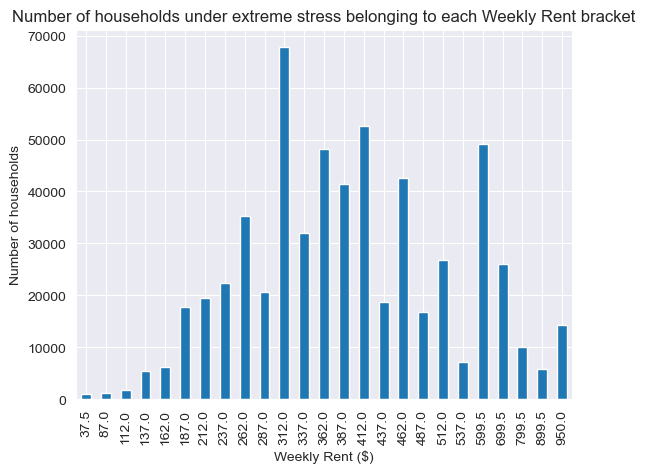

In [27]:
extreme_rent_households.plot(kind='bar')
plt.title('Number of households under extreme stress belonging to each Weekly Rent bracket')
plt.xlabel('Weekly Rent ($)')
plt.ylabel('Number of households')
plt.show()